# Shared-B variant

Generated from the notebook of the same name without the `_sharedB` suffix.
The **only** substantive difference is `shared_loadings=True` on both `DesignSpec`s:
one loading matrix $B$ is drawn once at $p_{\max}$ and **every** replicate is scored
against that same truth, with $p$ walking its prefixes — the design the paper text
describes ("this loading matrix $B$ is fixed for all 1000 paths"). The default
notebooks instead redraw $B$ per replicate, averaging over universes.

The factor and idiosyncratic draws are bit-identical between the two designs, so the
B-free theory quantities (`floor`, `rhs`, `rotation` — the bands) are unchanged; only
the loading geometry moves. Caches and figure outputs are written to `*_sharedB` /
`*-sharedB` paths so the two variants never collide.


# ex-6 rotation figures — scalar views only (no disk/radar panels)

The in-subspace rotation figures from `ex-6_insub_rotation_mono`, lifted into their own
notebook for the Figure 2 review: the measured-vs-limit bars, the per-replicate
distribution, the tail tables, and the component-colored (paper) versions of the first
two. Every disk / polar panel is deliberately left behind in `ex-6_insub_rotation_mono`
and `ex-6_radar_disks`.

Figures are carried over **verbatim**, including the two labels the collaborator flagged,
so the artifact under discussion is reproduced exactly as published before any fix.

In [1]:
import sys
from io import BytesIO
from pathlib import Path

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "sim").is_dir():
    if REPO_ROOT == REPO_ROOT.parent:
        raise FileNotFoundError("could not locate repo root (no 'sim' dir above cwd)")
    REPO_ROOT = REPO_ROOT.parent
for _p in (str(REPO_ROOT), str(REPO_ROOT / "sim")):
    if _p not in sys.path:
        sys.path.insert(0, _p)

from loguru import logger
logger.remove()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from fl_experiment_setup import ModelSpec, DesignSpec
from fl_experiment_runner import run_experiment
from fl_plot import (grid, Row, Band, MeanCI, BoxDist, RefOverlay,
                     Theme, THEME)

DATA_DIR = REPO_ROOT / "nb_outputs"
OUT_DIR = REPO_ROOT / "nb_outputs" / "ex6_rotation_figures-sharedB"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ONE color for every per-factor mark (factors are not compared across panels);
# ci_caps zeroed out -> measured-mean dots carry no error bars.
FACTOR_HATCHES = ("", "//", "xx", "..", "\\\\", "++")   # per-factor identity, colorless
MONO_THEME = Theme(factor_colors=("tab:gray",) * 6,
                   factor_cmaps=("Blues",) * 6,
                   factor_hatches=FACTOR_HATCHES,
                   ci_caps=dict(fmt="none", ecolor="black", elinewidth=0.0, capsize=0))
FIG_FORMATS = ("pdf",)
SAVE_FIGS = False   # default: figures are NOT written to disk; enable one with out(..., save=True)


def out(stem, save=None):
    """out_path for grid(): OUT_DIR/stem when saving is on (globally via
    SAVE_FIGS, or per-figure via save=True), else None."""
    return OUT_DIR / stem if (SAVE_FIGS if save is None else save) else None


def show(fig):
    buf = BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight")
    display(Image(data=buf.getvalue()))
    plt.close(fig)


# Canonical diagonal-Gram model (factor 1 market-like, c = [1.25, 1, 1]).
model = ModelSpec(
    k_factors=3,
    factor_vols=[0.16, 0.08, 0.06],
    beta_samplers=[
        {"distribution": "normal", "loc": 1.0, "scale": 0.5},
        {"distribution": "normal", "loc": 0.0, "scale": 1.0},
        {"distribution": "normal", "loc": 0.0, "scale": 1.0},
    ],
    idio_vol_sampler={"distribution": "constant", "value": 0.4},
)
HEAVY_TAIL = dict(
    factor_return_sampler={"distribution": "student_t", "df": 6, "loc": 0.0, "scale": 1.0},
    idio_return_sampler={"distribution": "student_t", "df": 5, "loc": 0.0, "scale": 1.0},
)
N_REPS, SEED = 1000, 20260511
_TAILS = r"(Factor Returns ~ $\mathcal{T}_6$, Idiosyncratic Returns ~ $\mathcal{T}_5$)"
print("ready")

ready


## Step 1 — record the projection coordinates

Only what `Experiment.record()` scalarizes reaches the DataFrame; everything else the
analyses compute is discarded. The ex-2 v2 sweeps kept the *angles* but dropped the
*coordinates* behind them — and the disks need coordinates. So this notebook's experiment
records, per replicate and factor:

* `hb1..hb3` — $\langle b_i, h_j\rangle$: coordinates of the projected estimate in the
  population basis, $\Pi h_j = \sum_i \mathrm{hb}_i\, b_i$. Everything else about the
  in-subspace geometry derives from these three numbers:
  $\lVert\Pi h_j\rVert^2 = \sum_i \mathrm{hb}_i^2$ and
  $\cos\angle(\Pi h_j, b_j) = |\mathrm{hb}_j| / \lVert\Pi h_j\rVert$;
* `nu1..nu3` — components of $\hat\nu_j$ (eigenvector of the $k\times k$ realized factor
  Gram) in the $e$-basis: the $p\to\infty$ limit direction for the same replicate.

Classes are carried from ex-2 v2 (no `.py` files touched): `ProjectedSpectrumAnalysis`
adds `h_coords` to the dual-Gram PCA, and `Eq6RHSWithNu` subclasses the shared RHS
analysis to expose the $\hat\nu$ coordinates it already computes internally. Signs are
stored **raw** — `eigh` fixes no sign convention — and folded at plot time, so the data
stays unopinionated.


In [2]:
from sim_theorem_partii import Eq6RHSAnalysis
from factor_lab.analyses.spectral import compute_true_eigenvalues
from factor_lab.analyses import compute_sine_alignment
from fl_experiment_setup import BaseExperiment


class Eq6RHSWithNu(Eq6RHSAnalysis):
    """Eq6RHSAnalysis plus the eigenvector coordinates of the k×k realized Gram."""

    def analyze(self, context) -> dict:
        result = super().analyze(context)
        k, n = context.k, context.T
        F = context.factor_returns.T
        if self.center:
            F = F - F.mean(axis=1, keepdims=True)
        # Use the same true population GB diagonal as the parent's analyze()
        # (see Eq6RHSAnalysis docstring) rather than re-deriving an empirical,
        # p-truncated estimate from context.model.B a second time here.
        c_half = np.sqrt(np.asarray(self.GB_diag[:k], dtype=float))
        D_hat = (c_half[:, None] * (F @ F.T / n)) * c_half[None, :]
        vals, vecs = np.linalg.eigh(D_hat)
        result["nu_coords"] = vecs[:, np.argsort(vals)[::-1]]      # (k, k), col j = ν̂_j
        return result


class ProjectedSpectrumAnalysis:
    """Dual-Gram PCA with the eq.(18) split AND the raw projection coordinates."""

    def __init__(self, population_loading_directions_b_pop, loading_frame, center: bool = True):
        self.population_loading_directions_b_pop = population_loading_directions_b_pop
        self.loading_frame = loading_frame          # notional frame ℓ: normalized loading rows
        self.center = center

    def analyze(self, context) -> dict:
        k = context.k
        Y = context.security_returns.T
        if self.center:
            Y = Y - Y.mean(axis=1, keepdims=True)
        p, n = Y.shape
        G = Y.T @ Y
        eigenvalues, eigenvectors = np.linalg.eigh(G)
        order = np.argsort(eigenvalues)[::-1]
        top_k = order[:k]
        sv = np.sqrt(np.maximum(eigenvalues[top_k], 0.0))
        H = (Y @ eigenvectors[:, top_k]) / np.where(sv > 1e-14, sv, 1.0)   # (p, k)
        sin2_angle, _ = compute_sine_alignment(
            self.population_loading_directions_b_pop, H.T)
        coeffs = self.population_loading_directions_b_pop @ H              # (k, k)
        in_subspace = (coeffs ** 2).sum(axis=0)
        l_coords = self.loading_frame @ H                                  # (k, k): h_j vs the ℓ frame
        frame_diag = np.abs(np.diag(
            self.loading_frame @ self.population_loading_directions_b_pop.T))  # |⟨ℓ_i, b_i⟩| per rep
        return {"sin2_j": sin2_angle,
                "measured_out_of_subspace": 1.0 - in_subspace,             # ‖Π⊥h_j‖²
                "h_coords": coeffs,                                        # col j = Π h_j in b-basis
                "l_coords": l_coords, "frame_diag": frame_diag}


class InSubRotationExperiment(BaseExperiment):
    def __init__(self, center: bool = True):
        self.center = center

    def cell_setup(self, model, n: int, p: int):
        _, b_pop = compute_true_eigenvalues(model, model.k)
        ell = model.B / np.linalg.norm(model.B, axis=1, keepdims=True)     # notional frame ℓ
        return [ProjectedSpectrumAnalysis(b_pop, ell, center=self.center),
                Eq6RHSWithNu(center=self.center)]

    def record(self, n: int, p: int, merged: dict) -> list[dict]:
        k = len(merged["sin2_j"])
        C, W = merged["h_coords"], merged["nu_coords"]
        Lc, fd = merged["l_coords"], merged["frame_diag"]
        rows = []
        for j in range(k):
            rows.append({
                "n": n, "p": p, "j": j + 1,
                "sin2_j": float(merged["sin2_j"][j]),
                "rhs": float(merged["rhs"][j]), "floor": float(merged["floor"][j]),
                "rotation": float(merged["rotation"][j]),
                "measured_out_of_subspace": float(merged["measured_out_of_subspace"][j]),
                **{f"hb{i + 1}": float(C[i, j]) for i in range(k)},
                **{f"nu{i + 1}": float(W[i, j]) for i in range(k)},
                **{f"lb{i + 1}": float(Lc[i, j]) for i in range(k)},
                **{f"frame{i + 1}": float(fd[i]) for i in range(k)},
            })
        return rows

print("experiment classes defined")

experiment classes defined


## Step 2 — run or load the sweeps

Identical designs and seed to ex-2 v2 (nested sampling, time-nested), so every scalar
column here reproduces that notebook's numbers exactly — this frame is a strict superset.
First execution runs both sweeps (~3 min) and caches to `ex6_sharedB_df_{p,n}.parquet`; the guard
re-runs only if the cache is missing, mismatched, or lacks the coordinate columns.


In [3]:
design_p = DesignSpec(
    n_values=[63], p_values=[100, 500, 5000, 10000, 20000, 50000],
    n_reps=N_REPS, random_seed=SEED, sampling="nested", nest_time=True, shared_loadings=True, **HEAVY_TAIL,
)
design_n = DesignSpec(
    n_values=[20, 30, 45, 60, 63, 90, 120, 180, 250], p_values=[3000],
    n_reps=N_REPS, random_seed=SEED, sampling="nested", nest_time=True, shared_loadings=True, **HEAVY_TAIL,
)

_REQ = ({"hb1", "hb2", "hb3", "nu1", "nu2", "nu3", "rotation"}
        | {"lb1", "lb2", "lb3", "frame1", "frame2", "frame3"})


def load_or_run(path, design, label):
    if path.exists():
        d = pd.read_parquet(path)
        if (_REQ <= set(d.columns)
                and sorted(d["n"].unique()) == sorted(design.n_values)
                and sorted(d["p"].unique()) == sorted(design.p_values)
                and int(d.groupby(["n", "p", "j"]).size().max()) == design.n_reps):
            print(f"{label}: loaded cached sweep {path.name} ({len(d):,} rows)")
            return d
        print(f"{label}: cache mismatch — re-running")
    d = run_experiment(model, design, InSubRotationExperiment(), progress=True)
    d.to_parquet(path)
    print(f"{label}: ran sweep ({len(d):,} rows) → {path.name}")
    return d


df_p = load_or_run(DATA_DIR / "ex6_sharedB_df_p.parquet", design_p, "growing-p")
df_n = load_or_run(DATA_DIR / "ex6_sharedB_df_n.parquet", design_n, "growing-n")

replicate:   0%|          | 0/1000 [00:00<?, ?rep/s]

replicate:   0%|          | 1/1000 [00:00<02:58,  5.61rep/s]

replicate:   0%|          | 2/1000 [00:00<02:18,  7.23rep/s]

replicate:   0%|          | 3/1000 [00:00<02:03,  8.04rep/s]

replicate:   0%|          | 4/1000 [00:00<01:57,  8.51rep/s]

...

replicate:  98%|█████████▊| 985/1000 [00:19<00:00, 50.93rep/s]

replicate:  99%|█████████▉| 991/1000 [00:19<00:00, 51.04rep/s]

replicate: 100%|█████████▉| 997/1000 [00:19<00:00, 51.11rep/s]

replicate: 100%|██████████| 1000/1000 [00:19<00:00, 50.47rep/s]

growing-n: ran sweep (27,000 rows) → ex6_sharedB_df_n.parquet


## Step 3 — derive the plot columns, then verify them two independent ways

From the raw coordinates we derive everything the figures use:

* `sin2_in` — $1 - \mathrm{hb}_j^2 / \lVert\Pi h_j\rVert^2$, the in-subspace rotation
  **from coordinates**;
* `diff_in_rot` — its per-replicate difference from the $k\times k$ rotation;
* `hd2, hd3` / `nud2, nud3` — the unit-normalized, sign-folded disk coordinates for
  $\Pi h_j/\lVert\Pi h_j\rVert$ and $\hat\nu_j$. (Fold rule: flip each vector so its
  largest-magnitude coordinate is positive — a swapped $h_2$ lands at $+b_3$, not $-b_3$.)

Then two checks that must hold to machine precision, because they compute the same
quantity along different code paths:

1. `sin2_in` from coordinates **==** the exact-split identity
   $(\sin^2_j - \lVert\Pi^\perp h_j\rVert^2)/(1 - \lVert\Pi^\perp h_j\rVert^2)$ — catches
   any indexing slip in the recorded `hb*`;
2. $\sum_i \mathrm{hb}_i^2$ **==** $1 - \lVert\Pi^\perp h_j\rVert^2$ — the coordinates
   reconstruct the in-subspace mass.


In [4]:
def derive(df):
    C = df[["hb1", "hb2", "hb3"]].to_numpy()
    norm2 = (C ** 2).sum(axis=1)                       # ‖Π h_j‖²
    cjj = np.take_along_axis(C, (df["j"].to_numpy() - 1)[:, None], axis=1)[:, 0]
    sin2_in = 1.0 - cjj ** 2 / norm2                   # from coordinates
    # fold the arbitrary eigh sign by each vector's dominant coordinate
    sgn_h = np.sign(np.take_along_axis(C, np.abs(C).argmax(axis=1)[:, None], axis=1))[:, 0]
    W = df[["nu1", "nu2", "nu3"]].to_numpy()
    sgn_nu = np.sign(np.take_along_axis(W, np.abs(W).argmax(axis=1)[:, None], axis=1))[:, 0]
    nrm = np.sqrt(norm2)
    Lc = df[["lb1", "lb2", "lb3"]].to_numpy()
    sgn_l = np.sign(np.take_along_axis(Lc, np.abs(Lc).argmax(axis=1)[:, None], axis=1))[:, 0]
    return df.assign(
        sin2_in=sin2_in, diff_in_rot=df["rotation"] - sin2_in,   # limit − measured (predictor − realized)
        # unit-normalized in-subspace direction, sign-folded → comparable to ν̂
        hd1=sgn_h * C[:, 0] / nrm, hd2=sgn_h * C[:, 1] / nrm, hd3=sgn_h * C[:, 2] / nrm,
        nud1=sgn_nu * W[:, 0], nud2=sgn_nu * W[:, 1], nud3=sgn_nu * W[:, 2],
        # folded RAW cosines (no normalization): hf vs the b frame, lf vs the notional ℓ frame
        hf1=sgn_h * C[:, 0], hf2=sgn_h * C[:, 1], hf3=sgn_h * C[:, 2],
        lf1=sgn_l * Lc[:, 0], lf2=sgn_l * Lc[:, 1], lf3=sgn_l * Lc[:, 2],
        # angle gauge: each replicate at (cos, sin) of its TRUE angle to its own b_j —
        # polar angle in the plot = the actual angle ∠(b_j, h_j)
        ang_c=np.abs(cjj), ang_s=np.sqrt(np.clip(1.0 - cjj ** 2, 0.0, None)),
    )


df_p, df_n = derive(df_p), derive(df_n)

for nm, d in (("growing-p", df_p), ("growing-n", df_n)):
    ident = (d["sin2_j"] - d["measured_out_of_subspace"]) / (1 - d["measured_out_of_subspace"])
    print(f"{nm}: |sin2_in(coords) − sin2_in(identity)| max = "
          f"{(d['sin2_in'] - ident).abs().max():.2e};  "
          f"|‖c‖² − (1−oos)| max = "
          f"{((d[['hb1','hb2','hb3']]**2).sum(axis=1) - (1 - d['measured_out_of_subspace'])).abs().max():.2e}")
    


growing-p: |sin2_in(coords) − sin2_in(identity)| max = 2.28e-14;  |‖c‖² − (1−oos)| max = 5.55e-17
growing-n: |sin2_in(coords) − sin2_in(identity)| max = 2.26e-14;  |‖c‖² − (1−oos)| max = 5.55e-17


## Step 4 — compose the measured-vs-limit figures

First `fl_plot` composition, read it as a recipe:

* **top `Row`** stacks two marks on the same axes — `Band("rotation")` shades from 0 up to
  the limit's mean, and `MeanCI("sin2_in")` rides the measured mean (black dots, 95% CI
  caps) on top of it;
* **bottom `Row`** is `BoxDist("diff_in_rot")` — the per-replicate difference, dashed zero
  reference built in;
* `grid` supplies the factor columns, shared axes, legend (each mark contributes its own
  entry), and assembles the caption from the marks' fragments.

**What to look for:** the black dots start above the band (finite-$p$ idiosyncratic noise
adds rotation on average) and settle onto it; the boxes below collapse onto zero — the
pathwise convergence, with medians crossing zero harmlessly (~50% negative at large $p$ is
the signature of a correct limit, not a problem).


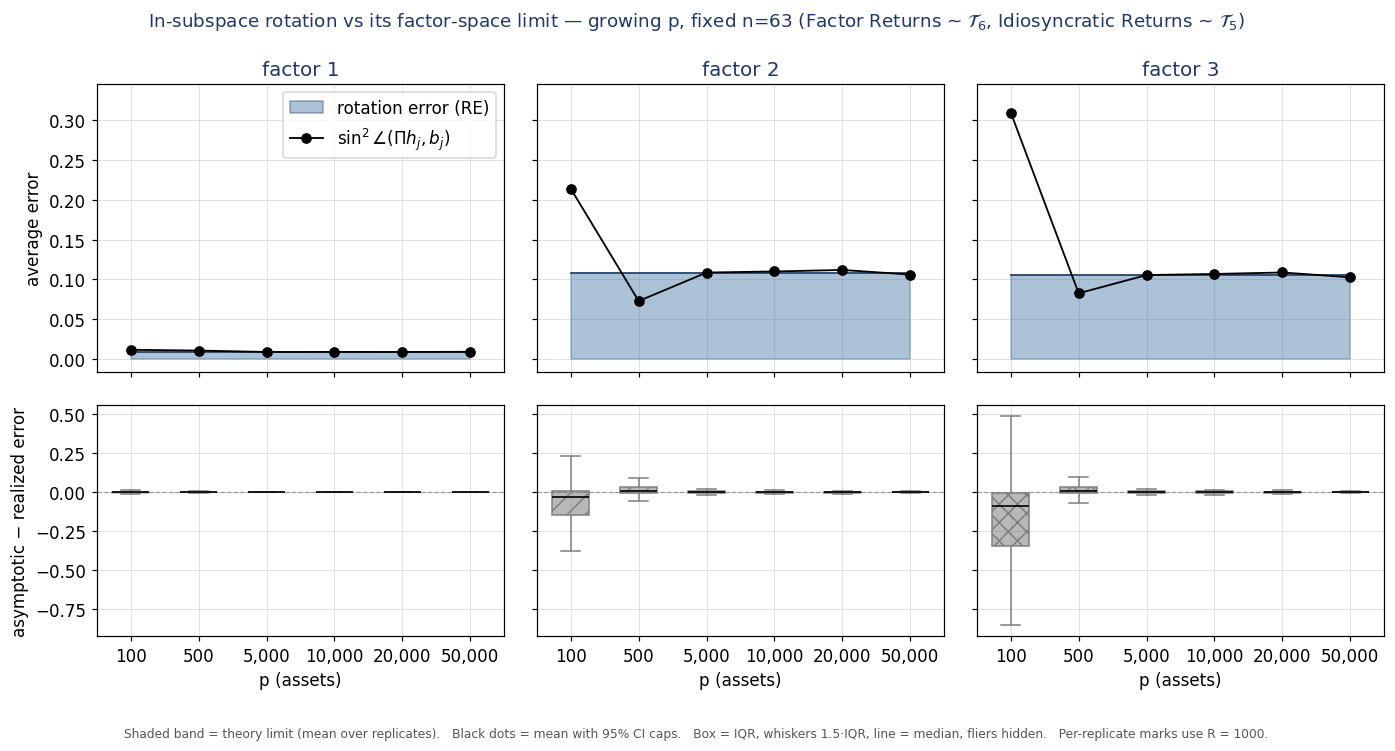

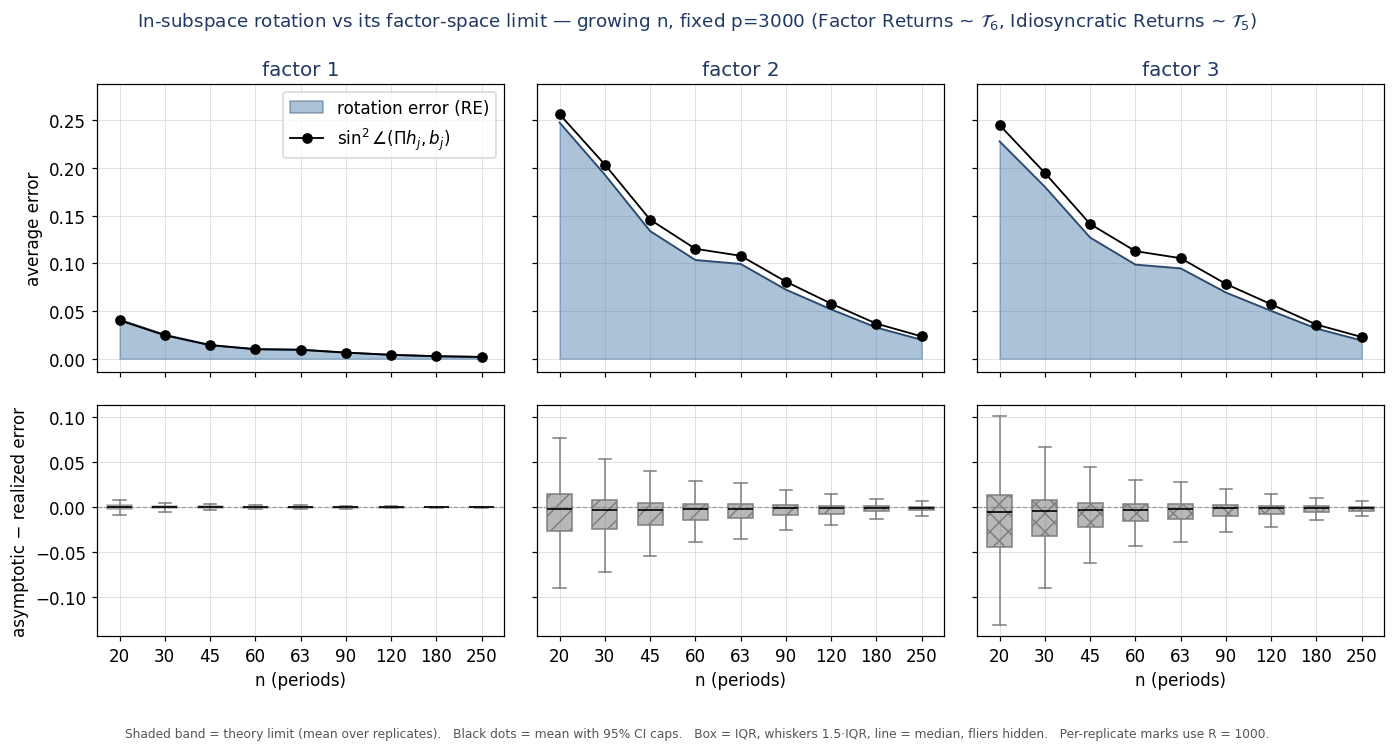

In [5]:
for df, key, lab in ((df_p, "p", "growing p, fixed n=63"),
                     (df_n, "n", "growing n, fixed p=3000")):
    fig, _ = grid(df, key,
                  rows=[Row([Band("rotation", label="rotation error (RE)"),
                             MeanCI("sin2_in", label=r"$\sin^2\angle(\Pi h_j, b_j)$")],
                            ylabel="average error", height=1.0),
                        Row(BoxDist("diff_in_rot"), ylabel="asymptotic − realized error")],
                  suptitle=f"In-subspace rotation vs its factor-space limit — {lab} {_TAILS}",
                  theme=MONO_THEME, formats=FIG_FORMATS, out_path=out(f"ex6_insub_vs_limit_{key}"))
    show(fig)

## Step 5 — the per-replicate distribution with the limit overlaid

Same data, distributional view: `BoxDist("sin2_in")` per swept value, with
`RefOverlay("rotation")` drawing the limit's median (dashed) and Q1–Q3 (translucent band)
on the same axis. One shared y across all panels (`sharey=True`, pinned to [0, 1]) so the
two sweeps are directly comparable.

**What to look for:** in the $p$-sweep the boxes descend onto a *flat* overlay — the limit
is a fixed-$n$ quantity that $p$ cannot improve; in the $n$-sweep both descend together.
The whiskers' upper tails for factors 2–3 are the identification-failure mass: at $n=63$
about 5% of replicates sit above 0.5 (the projected estimate more than 45° from its own
factor), and no amount of $p$ removes them.


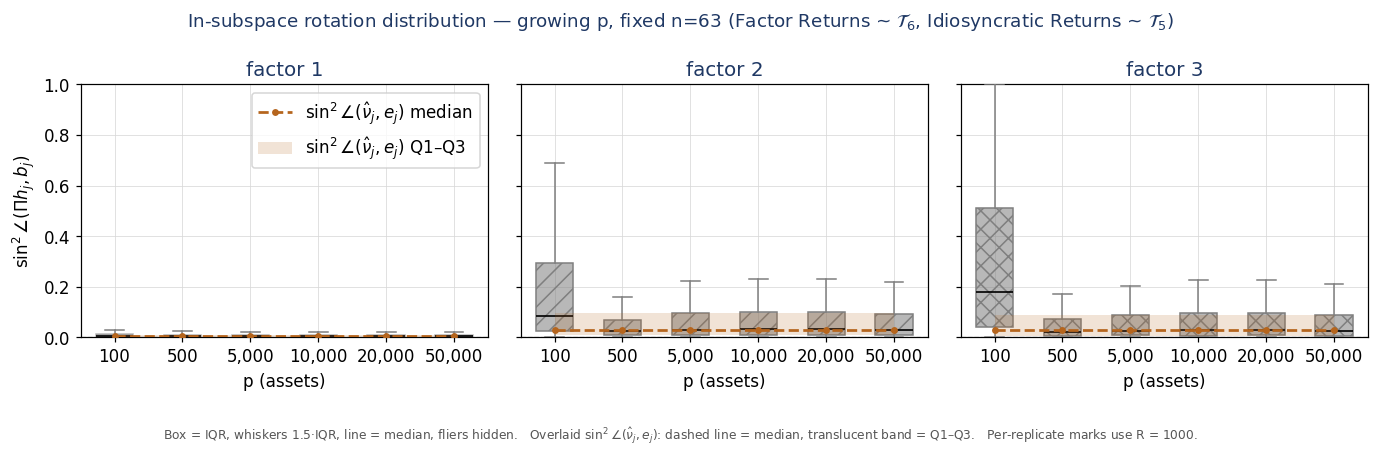

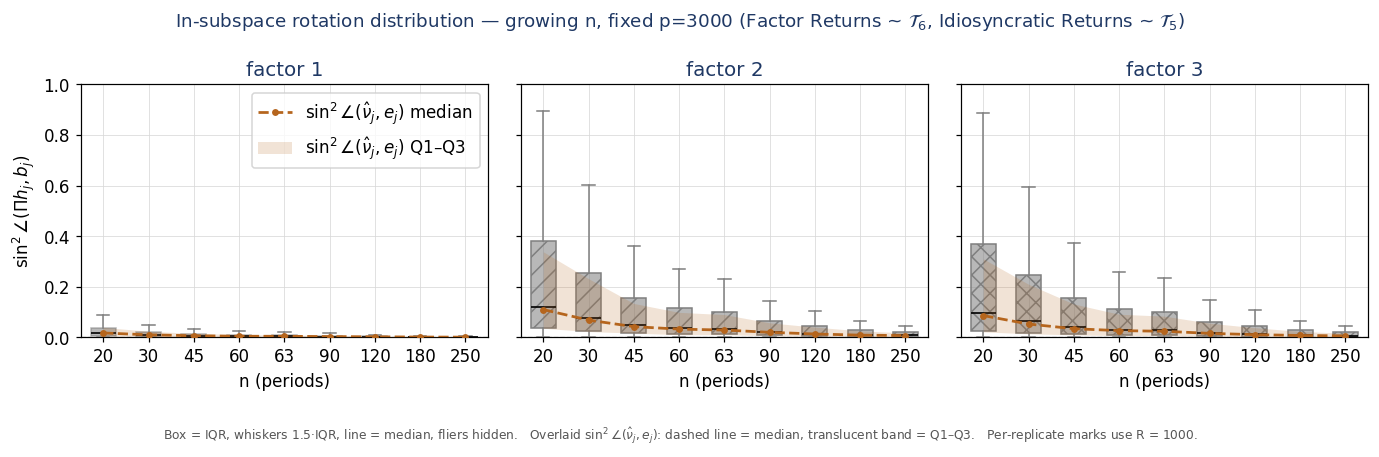

In [6]:
for df, key, lab in ((df_p, "p", "growing p, fixed n=63"),
                     (df_n, "n", "growing n, fixed p=3000")):
    fig, _ = grid(df, key,
                  rows=[Row([BoxDist("sin2_in"),
                             RefOverlay("rotation", label=r"$\sin^2\angle(\hat\nu_j, e_j)$")],
                            ylabel=r"$\sin^2\angle(\Pi h_j, b_j)$", ylim=(0, 1), height=1.0)],
                  sharey=True,
                  suptitle=f"In-subspace rotation distribution — {lab} {_TAILS}",
                  theme=MONO_THEME, formats=FIG_FORMATS, out_path=out(f"ex6_insub_dist_{key}"))
    show(fig)

## Step 7 — the numbers behind the pictures

Per (swept value, factor): median / Q3 / p95 of the in-subspace rotation, and
`frac_gt_half` = the fraction of replicates beyond 45° — the scalar shadow of the arc in
the disks. Read the p-sweep rows to confirm the plateau (medians stop moving after
$p\approx5000$) and the n-sweep rows to confirm the tail is what decays
(`frac_gt_half` → 0 while medians were small all along).


In [7]:
def tail_table(df, key):
    return (df.groupby([key, "j"])["sin2_in"]
              .agg(median="median", q3=lambda s: s.quantile(0.75),
                   p95=lambda s: s.quantile(0.95),
                   frac_gt_half=lambda s: (s > 0.5).mean())
              .round(4))

print("growing p (n=63):")
display(tail_table(df_p, "p"))
print("growing n (p=3000):")
display(tail_table(df_n, "n"))

growing p (n=63):


median      q3     p95  frac_gt_half
p     j                                      
100   1  0.0063  0.0134  0.0357         0.000
      2  0.0855  0.2942  0.8856         0.157
      3  0.1798  0.5132  0.9710         0.256
500   1  0.0054  0.0115  0.0314         0.001
      2  0.0247  0.0690  0.3062         0.031
      3  0.0220  0.0739  0.3871         0.039
5000  1  0.0047  0.0097  0.0262         0.000
      2  0.0303  0.0962  0.5473         0.060
      3  0.0267  0.0872  0.5488         0.060
10000 1  0.0046  0.0100  0.0265         0.000
      2  0.0321  0.1003  0.5387         0.057
      3  0.0276  0.0965  0.5414         0.058
20000 1  0.0047  0.0100  0.0263         0.000
      2  0.0324  0.0988  0.5516         0.059
      3  0.0281  0.0957  0.5483         0.060
50000 1  0.0047  0.0102  0.0260         0.000
      2  0.0313  0.0934  0.5094         0.053
      3  0.0266  0.0897  0.5130         0.054

growing n (p=3000):


median      q3     p95  frac_gt_half
n   j                                      
20  1  0.0168  0.0385  0.1502         0.006
    2  0.1187  0.3811  0.9400         0.198
    3  0.0960  0.3710  0.9375         0.188
30  1  0.0104  0.0233  0.0815         0.003
    2  0.0773  0.2557  0.8853         0.146
    3  0.0659  0.2481  0.8757         0.140
45  1  0.0067  0.0154  0.0441         0.001
    2  0.0482  0.1559  0.7127         0.087
    3  0.0419  0.1563  0.7279         0.088
60  1  0.0048  0.0114  0.0303         0.001
    2  0.0366  0.1170  0.5846         0.059
    3  0.0310  0.1110  0.5846         0.059
63  1  0.0045  0.0103  0.0288         0.001
    2  0.0328  0.0996  0.5566         0.056
    3  0.0286  0.0990  0.5508         0.056
90  1  0.0033  0.0070  0.0176         0.001
    2  0.0220  0.0631  0.4110         0.037
    3  0.0192  0.0624  0.4026         0.036
120 1  0.0025  0.0052  0.0124         0.000
    2  0.0152  0.0451  0.2788         0.026
    3  0.0132  0.0451  0.2724         0.027
180 1  0.0016  0.0033  0.0082         0.000
    2  0.0107  0.0287  0.1440         0.012
    3  0.0090  0.0274  0.1416         0.012
250 1  0.0012  0.0025  0.0061         0.000
    2  0.0078  0.0206  0.0718         0.005
    3  0.0070  0.0196  0.0726         0.005

---
## Component-colored versions (the paper figures)

The same two figures in the paper's treatment — green = rotation limit, orange = measured
— saved as `ex6_insub_vs_limit_{p,n}_qcolor`. The first of these is the collaborator's
**Figure 2**.

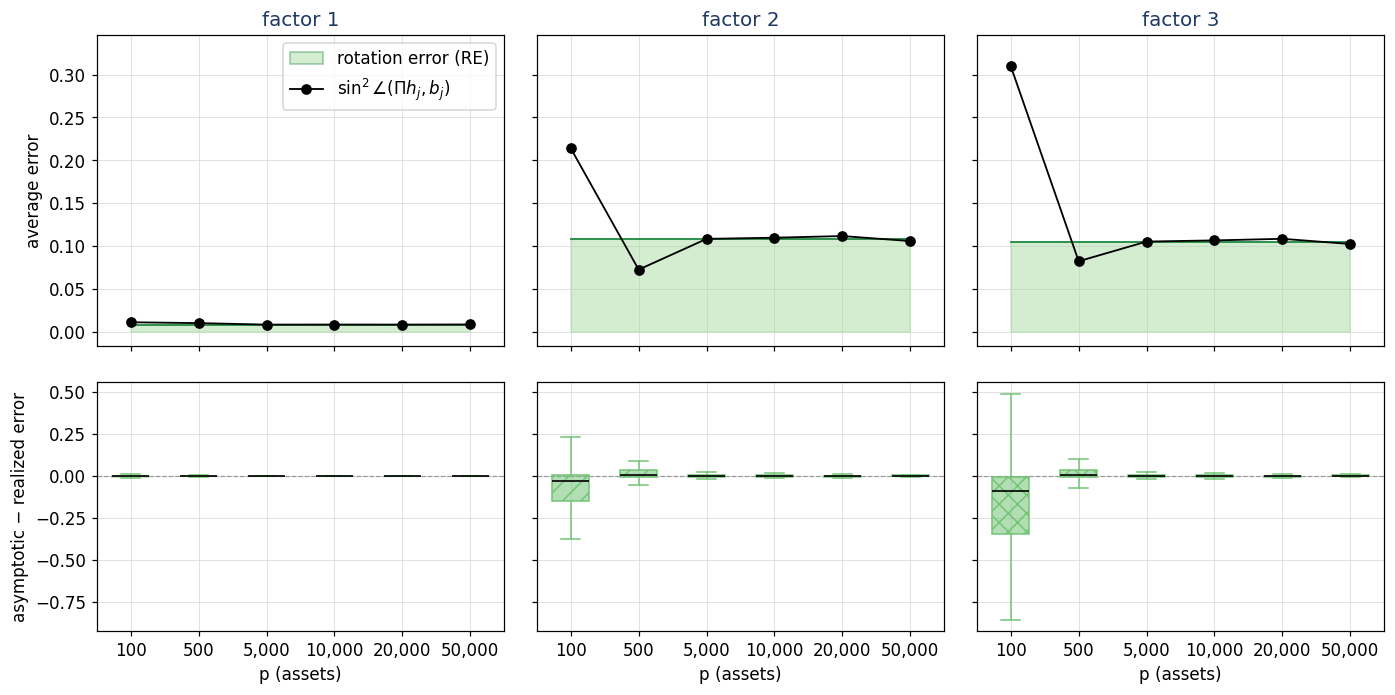

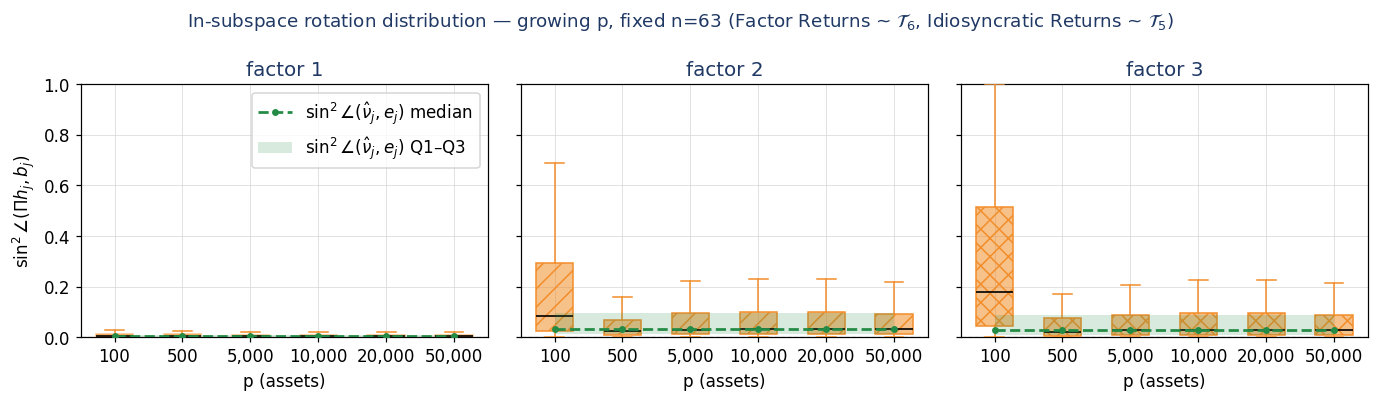

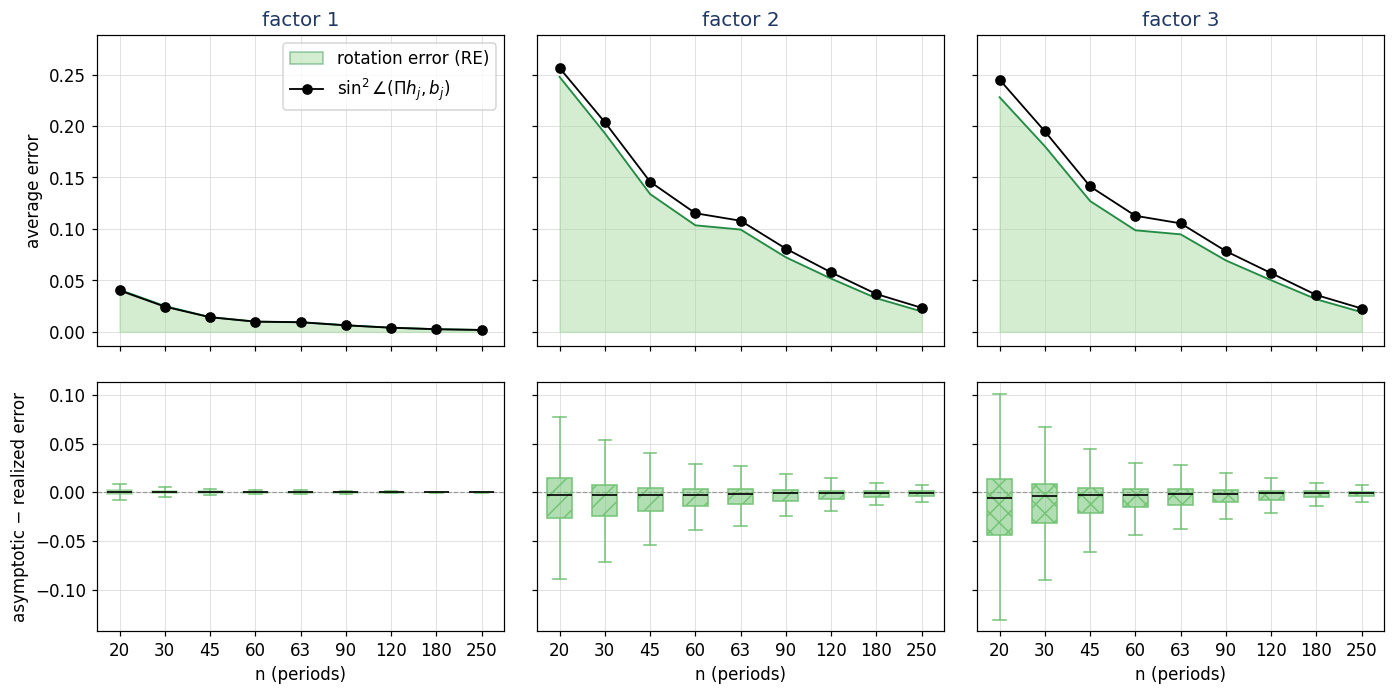

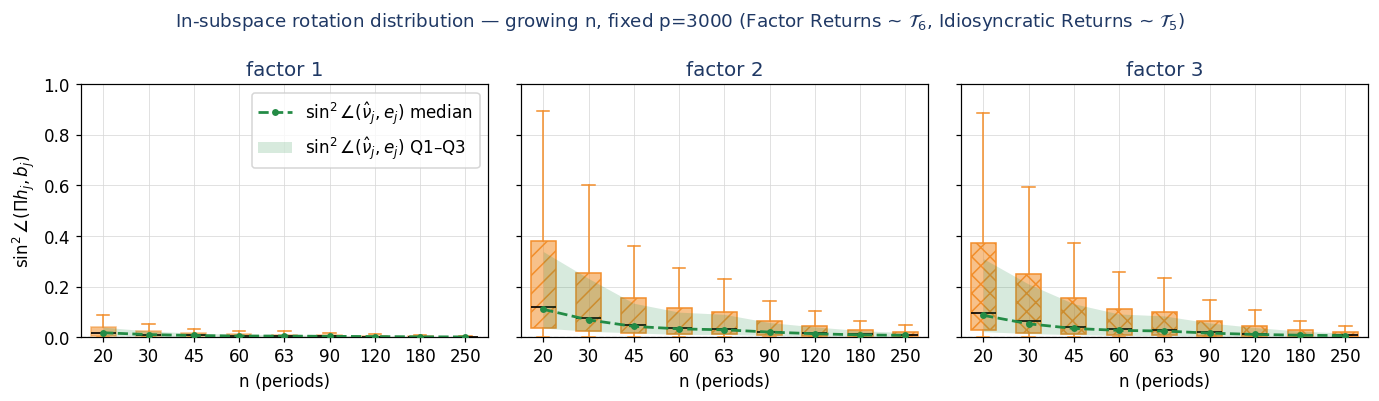

In [8]:
COMP_INSUB_THEME = Theme(factor_colors=("#f28e2b",) * 6, factor_cmaps=("Oranges",) * 6,
                         factor_hatches=FACTOR_HATCHES,
                         ci_caps=dict(fmt="none", ecolor="black", elinewidth=0.0, capsize=0))
COMP_ROT_FILL, COMP_ROT_LINE = "#a1d99b", "#238b45"
def comp_theme(color, cmap="Blues"):
    return Theme(factor_colors=(color,) * 6, factor_cmaps=(cmap,) * 6,
                 factor_hatches=FACTOR_HATCHES,
                 ci_caps=dict(fmt="none", ecolor="black", elinewidth=0.0, capsize=0))
ROT_T = comp_theme("#74c476", "Greens")

for df, key, lab in ((df_p, "p", "growing p, fixed n=63"),
                     (df_n, "n", "growing n, fixed p=3000")):
    # measured (orange) vs its rotation limit (green band)
    fig, _ = grid(df, key,
                  rows=[Row([Band("rotation", label="rotation error (RE)",
                                  fill=COMP_ROT_FILL, line=COMP_ROT_LINE),
                             MeanCI("sin2_in", label=r"$\sin^2\angle(\Pi h_j, b_j)$")],
                            ylabel="average error", height=1.0),
                        Row(BoxDist("diff_in_rot"), ylabel="asymptotic − realized error")],
                  # theme=COMP_INSUB_THEME,
                  theme=ROT_T,
                #   suptitle=f"In-subspace rotation vs its factor-space limit — {lab} {_TAILS}",
                  formats=FIG_FORMATS, out_path=out(f"ex6_insub_vs_limit_{key}_qcolor", save=True),
                  caption=False)
    show(fig)
    # distribution (orange boxes) with the rotation limit overlaid (green)
    fig, _ = grid(df, key,
                  rows=[Row([BoxDist("sin2_in"),
                             RefOverlay("rotation", label=r"$\sin^2\angle(\hat\nu_j, e_j)$",
                                        color=COMP_ROT_LINE)],
                            ylabel=r"$\sin^2\angle(\Pi h_j, b_j)$", ylim=(0, 1), height=1.0)],
                  sharey=True, theme=COMP_INSUB_THEME,
                  suptitle=f"In-subspace rotation distribution — {lab} {_TAILS}",
                  formats=FIG_FORMATS, out_path=out(f"ex6_insub_dist_{key}_qcolor"),
                  caption=False)
    show(fig)
